# Session 2 — KV Cache Memory Math

`KV_per_token = 2 x num_kv_heads x head_dim x num_layers x dtype_bytes`

`KV_cache_bytes = KV_per_token x seq_len x batch_size`

In [1]:
import sys; sys.path.insert(0, '../src')
from kv_cache_variants.memory_calc import kv_cache_bytes, human_bytes

configs = {
    'MHA (32 kv heads)': dict(num_kv_heads=32, head_dim=128),
    'GQA (8 kv heads)': dict(num_kv_heads=8, head_dim=128),
    'MQA (1 kv head)': dict(num_kv_heads=1, head_dim=128),
}
for name, cfg in configs.items():
    b = kv_cache_bytes(num_layers=32, seq_len=4096, **cfg)
    print(f'{name}: {human_bytes(b)}')

MHA (32 kv heads): 2.00 GB
GQA (8 kv heads): 512.00 MB
MQA (1 kv head): 64.00 MB


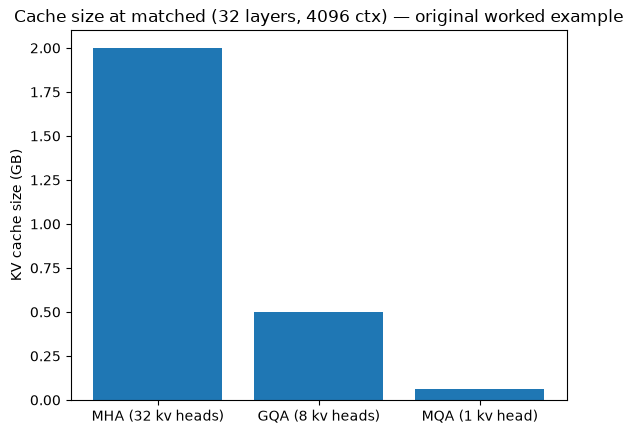

In [2]:
import matplotlib.pyplot as plt

names = list(configs.keys())
sizes_gb = [kv_cache_bytes(num_layers=32, seq_len=4096, **c) / 1024**3 for c in configs.values()]
plt.bar(names, sizes_gb)
plt.ylabel('KV cache size (GB)')
plt.title('Cache size at matched (32 layers, 4096 ctx) — original worked example')
plt.show()